In [1]:
!pip install langgraph langsmith

In [1]:
!pip install langchain langchain_groq langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [7]:
from google.colab import userdata
groq_api_key = userdata.get('GROQ_API_KEY')
langsmith_api_key= userdata.get('LANGSMITH_API_KEY')

In [8]:
import os
os.environ["LANGCHAIN_API_KEY"]= langsmith_api_key
os.environ["LANGCHAIN_TRACING_V2"]= "true"
os.environ["LANGCHAIN_PROJECT"]= "CourseLanggraph"

In [10]:
from langchain_groq import ChatGroq

In [27]:
llm = ChatGroq(groq_api_key = groq_api_key, model_name = "openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7fd081bd4fb0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fd081eb1460>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

### Start Building Chatbot Using Langgraph

In [28]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END # stategraph is for state management purpose
from langgraph.graph.message import add_messages

messages that have the type "list". The `add_messages` function in the annotation defines how this state key should be updated (in this case, it appends messages to the list, rather than overwriting them)

In [29]:
class State(TypedDict):
  messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)


In [30]:
graph_builder

In [31]:
def chatbot(state:State): #chatbot is inheriting from state class
  return{"messages":llm.invoke(state['messages'])}

In [32]:
graph_builder.add_node("chatbot", chatbot)

In [33]:
graph_builder

Now, it is time to connect the chatbot from start to end point

In [34]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

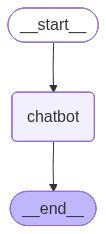

In [35]:
graph = graph_builder.compile()
graph

In [22]:
# from IPython.display import Image, display
# try:
#   display(Image(graph.get_graph().draw_mermaid_png()))
# except Exception:
#   pass

In [36]:
while True:
  user_input = input("User: ")
  if user_input.lower() in ["quit", "q"]:
    print("Good bye")
    break
  for event in graph.stream({'messages':("user", user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:", value["messages"].content)

User: hello
dict_values([{'messages': AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "hello". We should greet. Possibly ask how can help. No special instructions. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 72, 'total_tokens': 123, 'completion_time': 0.106520816, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.002786804, 'prompt_tokens_details': None, 'queue_time': 0.017599164, 'total_time': 0.10930762}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c9b3d7b164', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c4262-f4e3-7723-b399-ab52596f4a55-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 51, 'total_tokens': 123, 'output_token_details': {'reasoning': 33}})}])
content='Hello! How can I